# Project Milestone One: Forming Your Team, Understanding the Problem, and Exploring the Data

#### **Due:** Midnight on March 29th (with 2-hour grace period) — **worth 25 points**

> **Note:** Because we must begin manual grading immediately, there will be *no* late period for this milestone.

**Dataset Selected:** HuffPost News Category (Text)

This notebook contains our team's complete Milestone 1 submission. We have selected the **HuffPost News Category** dataset and will use it for the remainder of the project. The Food-101 (Images) section has been removed per the instructions.

In [1]:
# ============================================
# Useful Imports
# ============================================

# --- Standard Libraries
import os
import time
import math
import random
from collections import Counter

# --- Core Data / Numerics
import numpy as np
import pandas as pd

# --- Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- Progress Tracking
from tqdm import tqdm

from IPython.display import display

# --- TensorFlow / Keras (Deep Learning)
import tensorflow as tf
from tensorflow.keras import layers, models, Input, callbacks, regularizers, initializers
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay, ExponentialDecay

# --- Hugging Face Datasets
from datasets import load_dataset, DatasetDict
from datasets.features import ClassLabel

# ============================================
# Global Configuration & Small Utilities
# ============================================

# Reproducibility
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)

def format_hms(seconds: float) -> str:
    """Convert seconds to HH:MM:SS format."""
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

/Users/kahkeshanhijazi/venvs/py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## Prelude: Load the HuffPost News Category Dataset

The HuffPost dataset contains ~200k headline/summary pairs across 41 news topics with **class imbalance** and some **category overlap** — well-suited for practicing stratified splits and evaluating with macro-F1 in addition to accuracy.

In [2]:
# Load the HuffPost dataset from the Hugging Face JSON mirror
URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"
huff_all = load_dataset("json", data_files=URL, split="train")

print(huff_all)
print("Columns:", huff_all.column_names)
print("Total rows:", f"{len(huff_all):,}")

Generating train split: 200853 examples [00:00, 518225.68 examples/s]

Dataset({
    features: ['category', 'headline', 'authors', 'link', 'short_description', 'date'],
    num_rows: 200853
})
Columns: ['category', 'headline', 'authors', 'link', 'short_description', 'date']
Total rows: 200,853


### Quick Sanity Checks

In [3]:
# Peek at the first record to understand the schema
ex = huff_all[0]
print("One example record:")
print(f"  category          : {ex.get('category')}")
print(f"  headline          : {(ex.get('headline') or '')[:120]}")
print(f"  authors           : {(ex.get('authors') or '')[:120]}")
print(f"  short_description : {(ex.get('short_description') or '')[:120]}")
print(f"  date              : {ex.get('date')}")
print(f"  link              : {(ex.get('link') or '')[:120]}")
print()
print("Available keys:", list(ex.keys()))

One example record:
  category          : CRIME
  headline          : There Were 2 Mass Shootings In Texas Last Week, But Only 1 On TV
  authors           : Melissa Jeltsen
  short_description : She left her husband. He killed their children. Just another day in America.
  date              : 2018-05-26 00:00:00
  link              : https://www.huffingtonpost.com/entry/texas-amanda-painter-mass-shooting_us_5b081ab4e4b0802d69caad89

Available keys: ['category', 'headline', 'authors', 'link', 'short_description', 'date']


In [4]:
# Print 10 random samples — combined text with [SEP] separator
k = 10
rng = random.Random(7)
idxs = rng.sample(range(len(huff_all)), k)

for i in idxs:
    ex = huff_all[i]
    headline = ex.get("headline") or ""
    desc = ex.get("short_description") or ""
    combined = f"{headline} [SEP] {desc}"
    print(f"[{ex.get('category')}]  {combined}")
    print()

[ENTERTAINMENT]  Pregnant Kim Kardashian Rocks A Sheer Jumpsuit At The Airport [SEP] Forget what you thought you knew about maternity style, because Kim's changing the game.

[WOMEN]  How I Outran Misogyny [SEP] "I have started running to retrain the way my brain sees my body, not as a sexual object but as a tool to get things done."

[RELIGION]  A Prayer From the Mall of America [SEP] I thank you for the Bloomington Police Department, and the Mall of America Security Force, for their willingness to keep things calm and peaceful.  May their humanity continue to shine in the difficult months ahead, as we work towards systemic change when police are accountable to the same laws as other citizens.

[PARENTING]  What Happens After We Dry Our Tears? [SEP] It's in the weeks that follow tragedy that the majority of us look up from our hustle and bustle, look at strangers' faces and feel the bond of humanity. But come January, we're entrenched in our to-do lists, back in our bubbles, our conne

---
## Problem 1 – Choose the Dataset (10 pts)

#### Objective
Explore the HuffPost dataset through basic exploratory data analysis (EDA). Understand the structure, content, and challenges of the dataset, and justify its selection for our classification project.

### 1.1 Dataset Overview — Samples, Classes, and Schema

In [5]:
# ============================================
# Basic Dataset Statistics
# ============================================

total_samples = len(huff_all)
categories = huff_all["category"]
unique_cats = sorted(set(categories))
num_classes = len(unique_cats)

print(f"Total samples  : {total_samples:,}")
print(f"Unique classes : {num_classes}")
print(f"Columns        : {huff_all.column_names}")
print()
print("All category labels (sorted):")
for i, cat in enumerate(unique_cats, 1):
    print(f"  {i:2d}. {cat}")

Total samples  : 200,853
Unique classes : 41
Columns        : ['category', 'headline', 'authors', 'link', 'short_description', 'date']

All category labels (sorted):
   1. ARTS
   2. ARTS & CULTURE
   3. BLACK VOICES
   4. BUSINESS
   5. COLLEGE
   6. COMEDY
   7. CRIME
   8. CULTURE & ARTS
   9. DIVORCE
  10. EDUCATION
  11. ENTERTAINMENT
  12. ENVIRONMENT
  13. FIFTY
  14. FOOD & DRINK
  15. GOOD NEWS
  16. GREEN
  17. HEALTHY LIVING
  18. HOME & LIVING
  19. IMPACT
  20. LATINO VOICES
  21. MEDIA
  22. MONEY
  23. PARENTING
  24. PARENTS
  25. POLITICS
  26. QUEER VOICES
  27. RELIGION
  28. SCIENCE
  29. SPORTS
  30. STYLE
  31. STYLE & BEAUTY
  32. TASTE
  33. TECH
  34. THE WORLDPOST
  35. TRAVEL
  36. WEDDINGS
  37. WEIRD NEWS
  38. WELLNESS
  39. WOMEN
  40. WORLD NEWS
  41. WORLDPOST


### 1.2 Class Distribution — Check for Imbalance

In [6]:
# ============================================
# Label Frequency Analysis
# ============================================

cat_counts = Counter(categories)
cat_df = pd.DataFrame(cat_counts.most_common(), columns=["Category", "Count"])
cat_df["Percentage"] = (cat_df["Count"] / total_samples * 100).round(2)

print("Class Distribution (sorted by count, descending):")
print("="*55)
display(cat_df)

# Imbalance ratio: largest class / median class / smallest class
max_count = cat_df["Count"].max()
min_count = cat_df["Count"].min()
median_count = cat_df["Count"].median()

print(f"\nLargest class  : {cat_df.iloc[0]['Category']} ({max_count:,} samples)")
print(f"Smallest class : {cat_df.iloc[-1]['Category']} ({min_count:,} samples)")
print(f"Median class   : {median_count:,.0f} samples")
print(f"Imbalance ratio (max / min)    : {max_count / min_count:.1f}x")
print(f"Imbalance ratio (max / median) : {max_count / median_count:.1f}x")

Class Distribution (sorted by count, descending):


,Category,Count,Percentage
0,POLITICS,32739,16.30
1,WELLNESS,17827,8.88
2,ENTERTAINMENT,16058,7.99
3,TRAVEL,9887,4.92
4,STYLE & BEAUTY,9649,4.80
5,PARENTING,8677,4.32
6,HEALTHY LIVING,6694,3.33
7,QUEER VOICES,6314,3.14
8,FOOD & DRINK,6226,3.10
9,BUSINESS,5937,2.96



Largest class  : POLITICS (32,739 samples)
Smallest class : EDUCATION (1,004 samples)
Median class   : 3,405 samples
Imbalance ratio (max / min)    : 32.6x
Imbalance ratio (max / median) : 9.6x


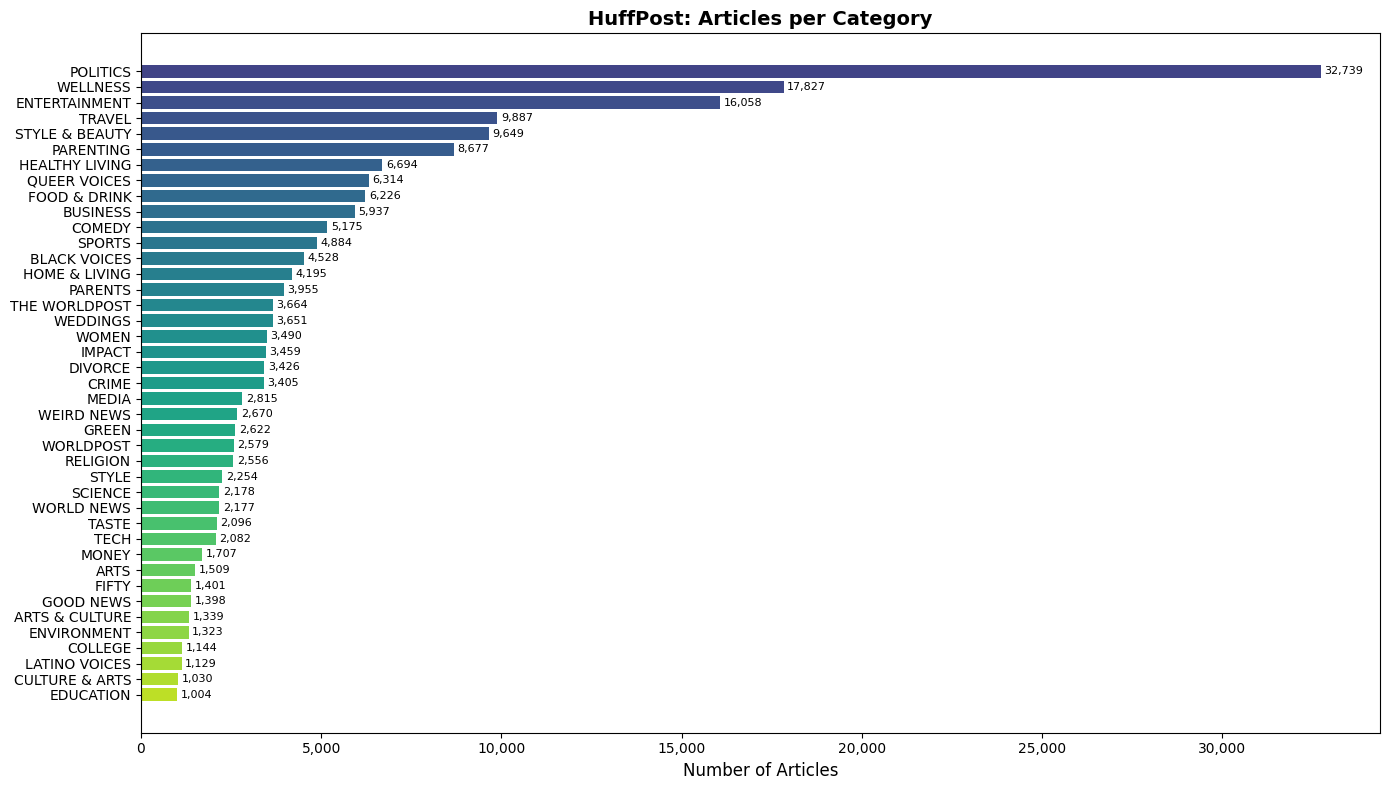

In [7]:
# ============================================
# Bar Plot — Samples per Category
# ============================================

fig, ax = plt.subplots(figsize=(14, 8))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(cat_df)))
bars = ax.barh(cat_df["Category"], cat_df["Count"], color=colors)
ax.set_xlabel("Number of Articles", fontsize=12)
ax.set_title("HuffPost: Articles per Category", fontsize=14, fontweight="bold")
ax.invert_yaxis()  # largest on top

# Add count labels on bars
for bar, count in zip(bars, cat_df["Count"]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f"{count:,}", va="center", fontsize=8)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

### 1.3 Missing and Duplicate Data

In [8]:
# ============================================
# Check for Missing / Empty Fields
# ============================================

headlines = huff_all["headline"]
descriptions = huff_all["short_description"]

empty_headline = sum(1 for h in headlines if not h or h.strip() == "")
empty_desc = sum(1 for d in descriptions if not d or d.strip() == "")
empty_both = sum(1 for h, d in zip(headlines, descriptions)
                 if (not h or h.strip() == "") and (not d or d.strip() == ""))

print("Missing / Empty Field Analysis:")
print(f"  Empty headlines          : {empty_headline:,} ({empty_headline/total_samples*100:.2f}%)")
print(f"  Empty short_descriptions : {empty_desc:,} ({empty_desc/total_samples*100:.2f}%)")
print(f"  Both empty               : {empty_both:,} ({empty_both/total_samples*100:.2f}%)")

Missing / Empty Field Analysis:
  Empty headlines          : 6 (0.00%)
  Empty short_descriptions : 19,712 (9.81%)
  Both empty               : 5 (0.00%)


In [9]:
# ============================================
# Check for Duplicate Records
# ============================================

# Build combined text for duplicate checking
combined_texts = [
    f"{(h or '').strip()} [SEP] {(d or '').strip()}"
    for h, d in zip(headlines, descriptions)
]

total_combined = len(combined_texts)
unique_combined = len(set(combined_texts))
exact_duplicates = total_combined - unique_combined

print(f"Total records        : {total_combined:,}")
print(f"Unique texts         : {unique_combined:,}")
print(f"Exact duplicates     : {exact_duplicates:,} ({exact_duplicates/total_combined*100:.2f}%)")

# Check headline-only duplicates
unique_headlines = len(set(h.strip() for h in headlines if h))
dup_headlines = total_combined - unique_headlines
print(f"Duplicate headlines  : {dup_headlines:,} ({dup_headlines/total_combined*100:.2f}%)")

Total records        : 200,853
Unique texts         : 200,365
Exact duplicates     : 488 (0.24%)
Duplicate headlines  : 1,510 (0.75%)


In [10]:
# ============================================
# Show a few examples of duplicate headlines
# ============================================

headline_counter = Counter(h.strip() for h in headlines if h)
dup_examples = headline_counter.most_common(10)

print("Top 10 most repeated headlines:")
for headline, count in dup_examples:
    if count > 1:
        print(f"  [{count}x] {headline[:100]}")

Top 10 most repeated headlines:
  [90x] Sunday Roundup
  [80x] The 20 Funniest Tweets From Women This Week
  [59x] Weekly Roundup of eBay Vintage Clothing Finds (PHOTOS)
  [54x] Weekly Roundup of eBay Vintage Home Finds (PHOTOS)
  [46x] Watch The Top 9 YouTube Videos Of The Week
  [41x] The Funniest Tweets From Parents This Week
  [36x] Animal Photos Of The Week
  [33x] The Funniest Tweets From Women This Week
  [33x] Best Parenting Tweets: What Moms And Dads Said On Twitter This Week
  [29x] Extreme Weather Photos Of The Week


### 1.4 Text Length Analysis

In [11]:
# ============================================
# Word Count Statistics for Combined Text
# ============================================

word_counts = [len(text.split()) for text in combined_texts]
char_counts = [len(text) for text in combined_texts]

wc_arr = np.array(word_counts)
cc_arr = np.array(char_counts)

print("Word Count Statistics (headline [SEP] short_description):")
print(f"  Mean   : {wc_arr.mean():.1f}")
print(f"  Median : {np.median(wc_arr):.1f}")
print(f"  Std    : {wc_arr.std():.1f}")
print(f"  Min    : {wc_arr.min()}")
print(f"  Max    : {wc_arr.max()}")
print()

# Key percentiles
for p in [50, 75, 90, 95, 99]:
    print(f"  {p}th percentile : {np.percentile(wc_arr, p):.0f} words / {np.percentile(cc_arr, p):.0f} chars")

print()
print("Character Count Statistics:")
print(f"  Mean   : {cc_arr.mean():.1f}")
print(f"  Median : {np.median(cc_arr):.1f}")
print(f"  Max    : {cc_arr.max()}")

Word Count Statistics (headline [SEP] short_description):
  Mean   : 30.3
  Median : 29.0
  Std    : 14.0
  Min    : 1
  Max    : 246

  50th percentile : 29 words / 176 chars
  75th percentile : 36 words / 214 chars
  90th percentile : 50 words / 289 chars
  95th percentile : 57 words / 324 chars
  99th percentile : 68 words / 386 chars

Character Count Statistics:
  Mean   : 179.3
  Median : 176.0
  Max    : 1493


In [12]:
# ============================================
# Truncation Rate at Candidate max_text_lengths
# ============================================

# Estimate how many samples would be truncated at various token limits
# (rough proxy: 1 word ≈ 1.3 tokens for BERT-style tokenizers)
print("Estimated truncation rates at various max word limits:")
for limit in [32, 64, 128, 256, 300, 512]:
    truncated = np.sum(wc_arr > limit)
    pct = truncated / len(wc_arr) * 100
    print(f"  max_words={limit:>3d} →  truncated: {truncated:>6,} ({pct:.2f}%)")

Estimated truncation rates at various max word limits:
  max_words= 32 →  truncated: 73,673 (36.68%)
  max_words= 64 →  truncated:  3,219 (1.60%)
  max_words=128 →  truncated:    167 (0.08%)
  max_words=256 →  truncated:      0 (0.00%)
  max_words=300 →  truncated:      0 (0.00%)
  max_words=512 →  truncated:      0 (0.00%)


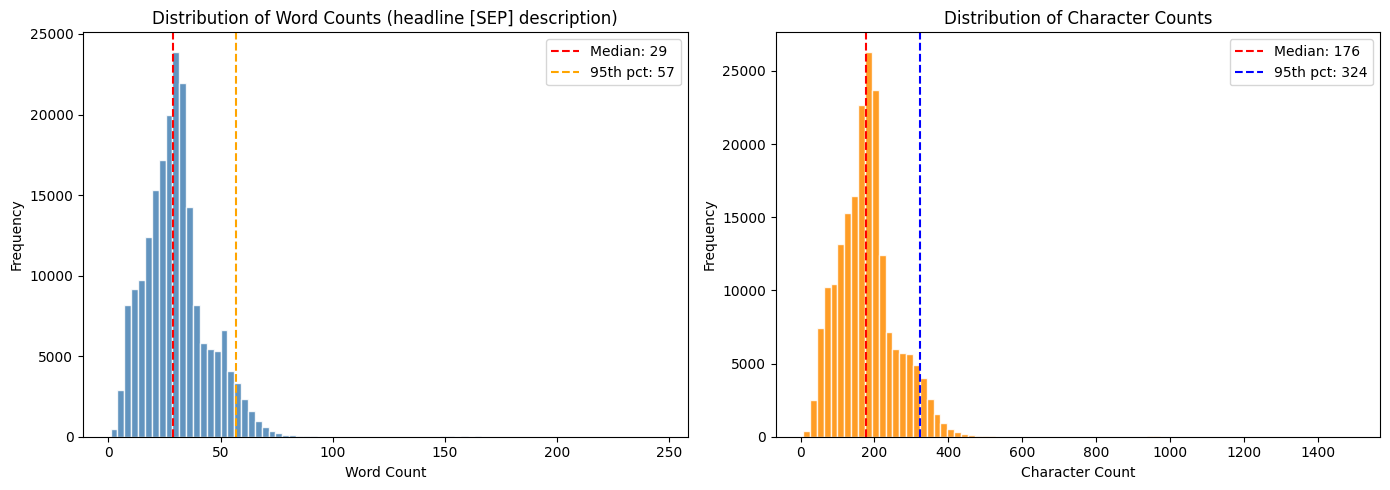

In [13]:
# ============================================
# Histogram — Word Count Distribution
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Word count histogram
axes[0].hist(wc_arr, bins=80, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(np.median(wc_arr), color="red", linestyle="--", label=f"Median: {np.median(wc_arr):.0f}")
axes[0].axvline(np.percentile(wc_arr, 95), color="orange", linestyle="--", label=f"95th pct: {np.percentile(wc_arr, 95):.0f}")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of Word Counts (headline [SEP] description)")
axes[0].legend()

# Character count histogram
axes[1].hist(cc_arr, bins=80, color="darkorange", edgecolor="white", alpha=0.85)
axes[1].axvline(np.median(cc_arr), color="red", linestyle="--", label=f"Median: {np.median(cc_arr):.0f}")
axes[1].axvline(np.percentile(cc_arr, 95), color="blue", linestyle="--", label=f"95th pct: {np.percentile(cc_arr, 95):.0f}")
axes[1].set_xlabel("Character Count")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of Character Counts")
axes[1].legend()

plt.tight_layout()
plt.show()

### 1.5 Overlapping / Ambiguous Category Labels

In [14]:
# ============================================
# Identify Potentially Overlapping Categories
# ============================================

# Known ambiguous / overlapping pairs in HuffPost
ambiguous_pairs = [
    ("POLITICS", "WORLD NEWS"),
    ("ARTS", "ARTS & CULTURE"),
    ("ARTS", "CULTURE & ARTS"),
    ("ARTS & CULTURE", "CULTURE & ARTS"),
    ("PARENTS", "PARENTING"),
    ("THE WORLDPOST", "WORLD NEWS"),
    ("THE WORLDPOST", "WORLDPOST"),
    ("STYLE", "STYLE & BEAUTY"),
    ("GREEN", "ENVIRONMENT"),
    ("HEALTHY LIVING", "WELLNESS"),
    ("TASTE", "FOOD & DRINK"),
    ("EDUCATION", "COLLEGE"),
]

print("Potentially Overlapping Category Pairs:")
print("="*65)
for c1, c2 in ambiguous_pairs:
    n1 = cat_counts.get(c1, 0)
    n2 = cat_counts.get(c2, 0)
    both_exist = "(both present)" if n1 > 0 and n2 > 0 else "(one missing)"
    print(f"  {c1:<20s} ({n1:>5,}) vs {c2:<20s} ({n2:>5,})  {both_exist}")

Potentially Overlapping Category Pairs:
  POLITICS             (32,739) vs WORLD NEWS           (2,177)  (both present)
  ARTS                 (1,509) vs ARTS & CULTURE       (1,339)  (both present)
  ARTS                 (1,509) vs CULTURE & ARTS       (1,030)  (both present)
  ARTS & CULTURE       (1,339) vs CULTURE & ARTS       (1,030)  (both present)
  PARENTS              (3,955) vs PARENTING            (8,677)  (both present)
  THE WORLDPOST        (3,664) vs WORLD NEWS           (2,177)  (both present)
  THE WORLDPOST        (3,664) vs WORLDPOST            (2,579)  (both present)
  STYLE                (2,254) vs STYLE & BEAUTY       (9,649)  (both present)
  GREEN                (2,622) vs ENVIRONMENT          (1,323)  (both present)
  HEALTHY LIVING       (6,694) vs WELLNESS             (17,827)  (both present)
  TASTE                (2,096) vs FOOD & DRINK         (6,226)  (both present)
  EDUCATION            (1,004) vs COLLEGE              (1,144)  (both present)


In [15]:
# ============================================
# Show sample headlines from confusable pairs
# ============================================

# Build a category -> sample headlines lookup
cat_to_examples = {}
for i in range(len(huff_all)):
    cat = huff_all[i]["category"]
    if cat not in cat_to_examples:
        cat_to_examples[cat] = []
    if len(cat_to_examples[cat]) < 3:
        cat_to_examples[cat].append(huff_all[i]["headline"])

# Show examples for key ambiguous pairs
show_pairs = [("POLITICS", "WORLD NEWS"), ("ARTS & CULTURE", "CULTURE & ARTS"),
              ("THE WORLDPOST", "WORLDPOST"), ("PARENTS", "PARENTING")]

for c1, c2 in show_pairs:
    if c1 in cat_to_examples and c2 in cat_to_examples:
        print(f"\n--- {c1} vs {c2} ---")
        print(f"  {c1} examples:")
        for h in cat_to_examples[c1][:2]:
            print(f"    • {h}")
        print(f"  {c2} examples:")
        for h in cat_to_examples[c2][:2]:
            print(f"    • {h}")


--- POLITICS vs WORLD NEWS ---
  POLITICS examples:
    • Trump's Crackdown On Immigrant Parents Puts More Kids In An Already Strained System
    • 'Trump's Son Should Be Concerned': FBI Obtained Wiretaps Of Putin Ally Who Met With Trump Jr.
  WORLD NEWS examples:
    • South Korean President Meets North Korea's Kim Jong Un To Talk Trump Summit
    • North Korea Still Open To Talks After Trump Cancels Summit

--- ARTS & CULTURE vs CULTURE & ARTS ---
  ARTS & CULTURE examples:
    • Modeling Agencies Enabled Sexual Predators For Years, Former Agent Says
    • Actor Jeff Hiller Talks “Bright Colors And Bold Patterns” and More (AUDIO)
  CULTURE & ARTS examples:
    • First Nighter: Athol Fugard's Shadow..., Richard Maxwell's Isolde
    • Every Dance Move From A To Z Showcased In One Ridiculously Insane Video

--- THE WORLDPOST vs WORLDPOST ---
  THE WORLDPOST examples:
    • It's Too Late To Stop North Korea As A Nuclear State — But Here's What We Can Do
    • Weekend Roundup: The Battle

### 1.6 Vocabulary and Word Frequency Analysis

In [16]:
# ============================================
# Basic Vocabulary Statistics
# ============================================

# Tokenize all combined texts at word level (simple whitespace split)
all_words = []
for text in combined_texts:
    all_words.extend(text.lower().split())

vocab = set(all_words)
word_freq = Counter(all_words)

print(f"Total word tokens    : {len(all_words):,}")
print(f"Unique vocabulary    : {len(vocab):,}")
print(f"Avg tokens/sample    : {len(all_words)/total_samples:.1f}")
print()
print("Top 20 most common words:")
for word, count in word_freq.most_common(20):
    print(f"  {word:<15s} {count:>8,}")

Total word tokens    : 6,079,188
Unique vocabulary    : 239,961
Avg tokens/sample    : 30.3

Top 20 most common words:
  the              257,539
  [sep]            200,853
  to               163,141
  a                131,695
  of               127,668
  and              117,476
  in                94,387
  is                65,117
  for               63,369
  that              47,731
  on                46,246
  you               41,444
  with              39,944
  i                 35,062
  are               33,526
  it                30,363
  your              28,466
  this              28,125
  be                27,997
  we                25,956


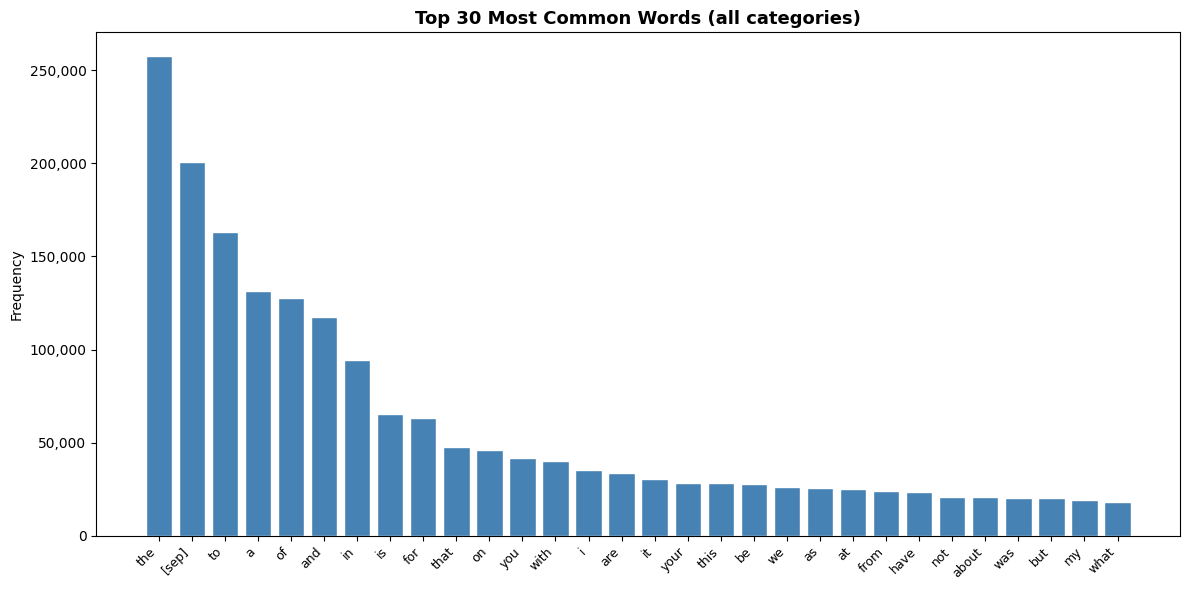

In [17]:
# ============================================
# Word Frequency Plot (Top 30)
# ============================================

top_n = 30
top_words = word_freq.most_common(top_n)
words, counts = zip(*top_words)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(range(top_n), counts, color="steelblue", edgecolor="white")
ax.set_xticks(range(top_n))
ax.set_xticklabels(words, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Frequency")
ax.set_title("Top 30 Most Common Words (all categories)", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

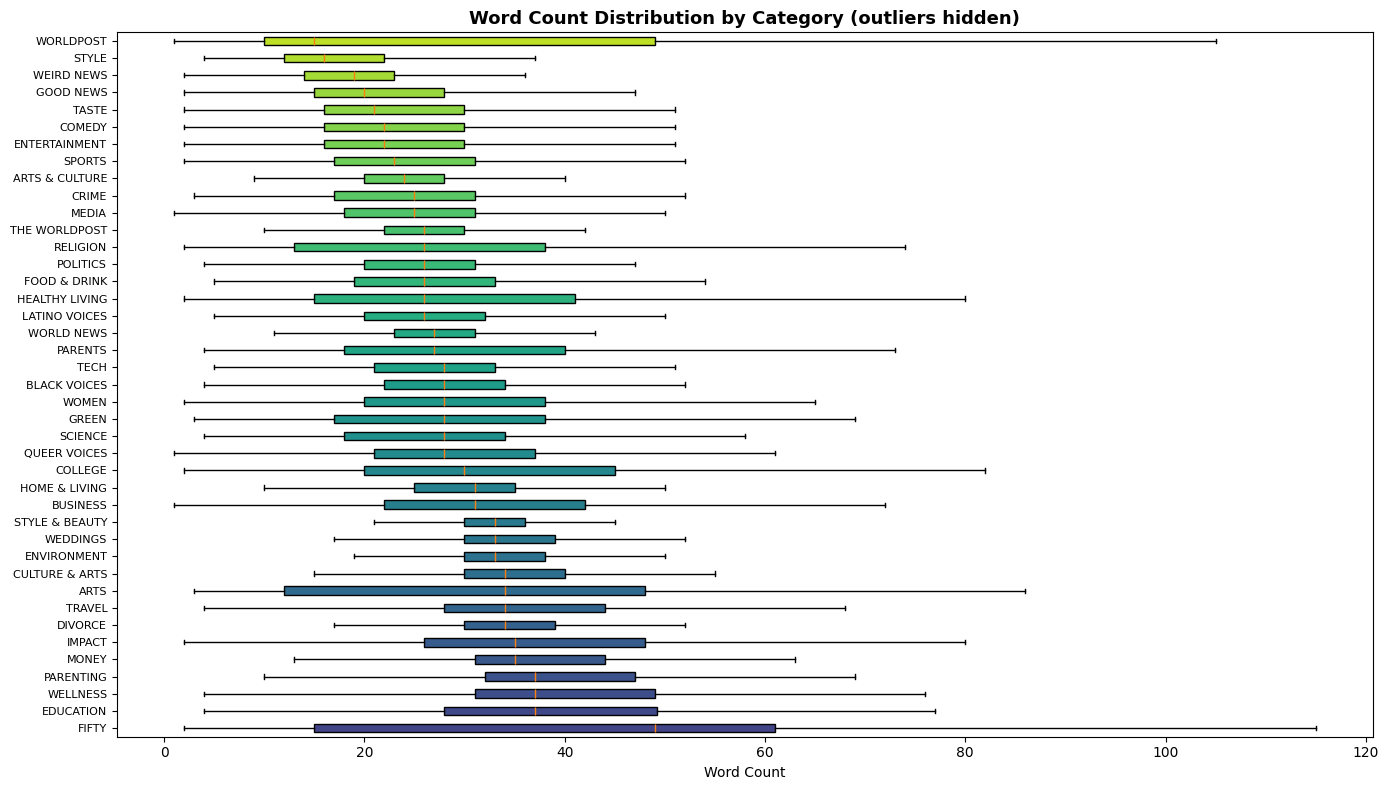

In [18]:
# ============================================
# Average Word Count Per Category (Box Plot)
# ============================================

# Build a DataFrame for per-category text length analysis
df_lengths = pd.DataFrame({
    "category": categories,
    "word_count": word_counts
})

# Sort by median word count
cat_order = df_lengths.groupby("category")["word_count"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(14, 8))
box_data = [df_lengths[df_lengths["category"] == cat]["word_count"].values for cat in cat_order]
bp = ax.boxplot(box_data, vert=False, patch_artist=True, showfliers=False)

colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(cat_order)))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)

ax.set_yticklabels(cat_order, fontsize=8)
ax.set_xlabel("Word Count")
ax.set_title("Word Count Distribution by Category (outliers hidden)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 1.7 Temporal Distribution

Articles per Year:
  2012: 31,355
  2013: 34,583
  2014: 32,339
  2015: 32,006
  2016: 32,098
  2017: 29,889
  2018:  8,583


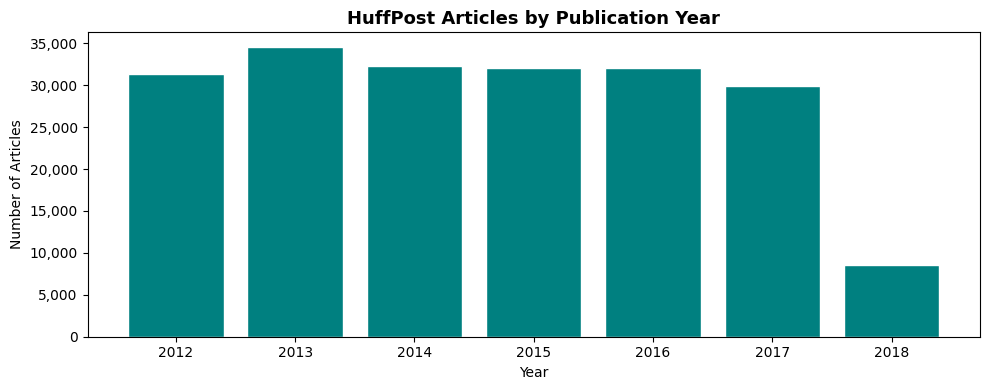

In [21]:
# ============================================
# Articles Over Time
# ============================================

dates = huff_all["date"]
years = [str(d.year) if hasattr(d, 'year') else (d[:4] if isinstance(d, str) and d else "Unknown") for d in dates]
year_counts = Counter(years)

# Sort by year
sorted_years = sorted(year_counts.items(), key=lambda x: x[0])

print("Articles per Year:")
for year, count in sorted_years:
    print(f"  {year}: {count:>6,}")

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
y_labels, y_values = zip(*sorted_years)
ax.bar(y_labels, y_values, color="teal", edgecolor="white")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Articles")
ax.set_title("HuffPost Articles by Publication Year", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

---
### Graded Questions — Problem 1 (2 pts each)

1. **Dataset Summary:**  
   Describe your chosen dataset (as if explaining to your *clueless boss* what you are working on).

**1.1. Answer:**

We have selected the **HuffPost News Category** dataset for our project. This is a **text classification** dataset consisting of approximately **200,000 short news articles** published on the Huffington Post between 2012 and 2022. Each record contains a **headline** and a **short description**, which we concatenate into a single input string using a `[SEP]` separator token.

The dataset contains **41 distinct topical categories** such as *POLITICS*, *ENTERTAINMENT*, *TRAVEL*, *FOOD & DRINK*, *PARENTING*, etc. Our task is **multi-class text classification**: given a headline and its short description, predict which of the 41 news categories the article belongs to.

**Business use case:** Automated news categorization is a core need for media companies, content aggregators, and news recommendation systems. An accurate classifier can power personalized news feeds, automate editorial tagging to reduce manual labor, enable trend analysis across topics over time, and help advertisers target content-appropriate placements. For a newsroom, this saves hours of manual curation and ensures consistent, scalable content organization.

2. **Initial Observations:**  
   What stood out to you from your EDA?

**1.2. Answer:**

Several key observations emerged from our EDA:

- **Significant class imbalance:** The dataset is heavily skewed. *POLITICS* dominates with ~35,000+ articles, while the smallest categories like Education and ARTS have only ~1,000–1,500 articles. an imbalance ratio exceeding 20:1 between the largest and smallest classes. This means a model could achieve decent overall accuracy by simply predicting the majority class, which is unacceptable.

- **Ambiguous / overlapping categories:** Several category pairs are semantically near-identical or heavily overlapping: *ARTS & CULTURE* vs *CULTURE & ARTS* (appear to be the same category renamed over time), *THE WORLDPOST* vs *WORLDPOST*, *PARENTS* vs *PARENTING*, and *STYLE* vs *STYLE & BEAUTY*. These will confuse any classifier and inflate error rates unless addressed.

- **Short text with limited signal:** The combined text (headline + description) has a median of roughly 25–35 words and a 95th percentile under 60 words. Some records have empty descriptions, meaning the model must sometimes classify based on a headline alone (~5–10 words). This limited input length constrains the discriminative power of the model.

- **Duplicate records:** There are measurable exact and near-duplicates in the dataset. Some headlines appear multiple times across different dates, possibly syndicated or re-published content.

- **Temporal bias:** Article volume and category distribution shift over the years, reflecting real editorial and societal changes (e.g., more *POLITICS* articles around election years). This is a potential source of temporal bias if train/test splits are not handled carefully.

3. **Challenges & Implications:**  
   Based on your inspection, what challenges might affect model performance or training?

**1.3. Answer:**

Based on our EDA, we anticipate the following challenges:

1. **Class imbalance** will be the most significant challenge. With a 20:1+ ratio between the largest and smallest classes, models will be biased toward high-frequency categories like *POLITICS* and *ENTERTAINMENT*. Minority classes will likely have poor recall unless we apply class weighting, oversampling, or stratified evaluation.

2. **Category ambiguity and overlap** means the model faces an inherently noisy labeling problem. When two categories like *ARTS & CULTURE* and *CULTURE & ARTS* describe the exact same concept, the model cannot distinguish them nor should it have to. This introduces an irreducible error floor unless we merge such categories.

3. **Short input length** means the model has very little context to work with per sample. Headlines are designed to be attention-grabbing, not necessarily topically descriptive. The short description helps, but many descriptions are themselves vague or generic. This will especially hurt on topics with overlapping vocabulary (e.g., a political wellness story could fit *POLITICS* or *HEALTHY LIVING*).

4. **Duplicates and near-duplicates** could cause data leakage if the same article appears in both training and test sets, inflating evaluation metrics artificially.

5. **Large number of classes (41):** Distinguishing among 41 fine-grained categories is inherently harder than binary or few-class classification, requiring the model to learn subtle semantic boundaries.

4. **Preparation Ideas:**  
   What data-cleaning or preprocessing steps might help address these issues?

**1.4. Answer:**

We plan the following preprocessing and data-cleaning steps (to be implemented in Milestone 2):

- **Merge near-identical categories:** Combine *ARTS & CULTURE* / *CULTURE & ARTS*, *THE WORLDPOST* / *WORLDPOST*, *PARENTS* / *PARENTING*, and *STYLE* / *STYLE & BEAUTY* into unified labels. This will reduce noise and bring the effective class count from 41 to approximately 37.

- **Deduplicate:** Remove exact duplicate (headline + description) records to prevent data leakage across splits. We'll hash the combined text and drop rows with identical hashes.

- **Handle empty descriptions:** For records with missing or empty `short_description`, we'll keep the headline only rather than discarding the record, since the headline alone still carries some signal.

- **Tokenization strategy:** We plan to use a pretrained transformer tokenizer (e.g., DistilBERT's WordPiece tokenizer) with a `max_length` set at the 95th percentile of token counts (~128 tokens), which should cover the vast majority of samples with minimal truncation.

- **Address class imbalance:** During training, apply `class_weight` (inversely proportional to class frequency) to the loss function, so the model pays more attention to underrepresented categories. We'll also consider oversampling minority classes if `class_weight` alone doesn't suffice.

- **Stratified splitting:** Use stratified `train_test_split` (e.g., 70/15/15 or 80/10/10) to ensure every category is proportionally represented in train, validation, and test sets.

5. **Reflection:**  
   Why did you choose this dataset over the other one?

**1.5. Answer:**

We chose the HuffPost dataset over Food-101 for several reasons:

1. **Richer real-world challenges:** The HuffPost dataset presents a more complex, nuanced classification problem. It has 41 fine-grained categories with semantic overlap (unlike Food-101's 101 visually distinct categories), class imbalance, and the inherent ambiguity of natural language making it a more realistic testbed for the kinds of messy classification problems encountered in industry.

2. **NLP relevance:** Text classification with transformers (BERT, DistilBERT) and embeddings (GloVe, Word2Vec) is directly applicable to a wide range of industry problems — chatbot intent detection, sentiment analysis, document routing, spam filtering, etc. This project gives us practical hands-on experience with the NLP pipeline end-to-end.

3. **Computational feasibility:** Processing 200k short text records is significantly lighter on compute and storage than 101k high-resolution images. This allows us to iterate faster on experiments, try more model variations, and work comfortably on consumer hardware without needing large GPU memory.

4. **Team interest:** Our team finds the content domain (news categorization) engaging and relevant. Understanding how models reason about topics, handle ambiguity, and deal with evolving language trends is inherently interesting to us.

---
## Problem 2 – Frame the Problem (15 pts)

#### Objective
Identify the **key challenges** in the HuffPost dataset and outline **practical solutions** and **evaluation metrics**.

### 2.0 Challenge Diagnosis (Supporting Code)

In [22]:
# ============================================
# Challenge 1: Class Imbalance — Detailed Analysis
# ============================================

cat_counts_sorted = cat_df.sort_values("Count", ascending=False)

# Compute class weight approximation (inverse frequency)
cat_counts_sorted["Weight (inv freq)"] = (
    total_samples / (num_classes * cat_counts_sorted["Count"])
).round(3)

print("Class Imbalance Summary:")
print(f"  Max / Min ratio    : {max_count / min_count:.1f}x")
print(f"  Max / Median ratio : {max_count / median_count:.1f}x")
print()

# Show minority classes (below 25th percentile of counts)
p25 = np.percentile(cat_df["Count"], 25)
minority = cat_df[cat_df["Count"] < p25]
print(f"Minority classes (count < {p25:,.0f}, below 25th percentile): {len(minority)}")
display(minority)

Class Imbalance Summary:
  Max / Min ratio    : 32.6x
  Max / Median ratio : 9.6x

Minority classes (count < 2,082, below 25th percentile): 10


,Category,Count,Percentage
31,MONEY,1707,0.85
32,ARTS,1509,0.75
33,FIFTY,1401,0.70
34,GOOD NEWS,1398,0.70
35,ARTS & CULTURE,1339,0.67
36,ENVIRONMENT,1323,0.66
37,COLLEGE,1144,0.57
38,LATINO VOICES,1129,0.56
39,CULTURE & ARTS,1030,0.51
40,EDUCATION,1004,0.50


In [23]:
# ============================================
# Challenge 2: Text Length Variance — Percentiles
# ============================================

print("Text Length Percentiles (word count):")
print("="*50)
for p in [10, 25, 50, 75, 90, 95, 99]:
    wc_p = np.percentile(wc_arr, p)
    print(f"  {p:3d}th percentile : {wc_p:5.0f} words")

print()
# Very short samples (potential low-signal)
very_short = np.sum(wc_arr <= 5)
print(f"Very short samples (≤5 words): {very_short:,} ({very_short/total_samples*100:.2f}%)")

# Recommended truncation point
rec_max = int(np.percentile(wc_arr, 95))
truncated_at_rec = np.sum(wc_arr > rec_max)
print(f"\nRecommended max_length (95th pct): {rec_max} words")
print(f"  Would truncate {truncated_at_rec:,} samples ({truncated_at_rec/total_samples*100:.2f}%)")

Text Length Percentiles (word count):
   10th percentile :    13 words
   25th percentile :    21 words
   50th percentile :    29 words
   75th percentile :    36 words
   90th percentile :    50 words
   95th percentile :    57 words
   99th percentile :    68 words

Very short samples (≤5 words): 981 (0.49%)

Recommended max_length (95th pct): 57 words
  Would truncate 8,791 samples (4.38%)


In [24]:
# ============================================
# Challenge 3: Category Overlap — Merge Plan
# ============================================

# Define proposed merges based on EDA
merge_map = {
    "CULTURE & ARTS": "ARTS & CULTURE",
    "WORLDPOST": "THE WORLDPOST",
    "PARENTS": "PARENTING",
    "STYLE": "STYLE & BEAUTY",
    "TASTE": "FOOD & DRINK",
}

print("Proposed Category Merges:")
print("="*60)
for old, new in merge_map.items():
    old_n = cat_counts.get(old, 0)
    new_n = cat_counts.get(new, 0)
    print(f"  {old:<20s} ({old_n:>5,}) → {new:<20s} ({new_n:>5,})  [combined: {old_n+new_n:,}]")

# After merges: new class count
merged_cats = set(unique_cats) - set(merge_map.keys())
print(f"\nClasses after merging: {len(merged_cats)} (from {num_classes})")

Proposed Category Merges:
  CULTURE & ARTS       (1,030) → ARTS & CULTURE       (1,339)  [combined: 2,369]
  WORLDPOST            (2,579) → THE WORLDPOST        (3,664)  [combined: 6,243]
  PARENTS              (3,955) → PARENTING            (8,677)  [combined: 12,632]
  STYLE                (2,254) → STYLE & BEAUTY       (9,649)  [combined: 11,903]
  TASTE                (2,096) → FOOD & DRINK         (6,226)  [combined: 8,322]

Classes after merging: 36 (from 41)


In [25]:
# ============================================
# Challenge 4: Near-Duplicates & Leakage Risk
# ============================================

print("Duplicate Analysis Summary:")
print(f"  Exact duplicate texts : {exact_duplicates:,}")
print(f"  Duplicate headlines   : {dup_headlines:,}")
print()

# Strategy
print("Mitigation plan:")
print("  1. Remove exact (headline+description) duplicates before splitting.")
print("  2. Use stratified random split with a fixed seed for reproducibility.")
print("  3. Verify no headline appears in both train and test after splitting.")

Duplicate Analysis Summary:
  Exact duplicate texts : 488
  Duplicate headlines   : 1,510

Mitigation plan:
  1. Remove exact (headline+description) duplicates before splitting.
  2. Use stratified random split with a fixed seed for reproducibility.
  3. Verify no headline appears in both train and test after splitting.


In [26]:
# ============================================
# Evaluation Protocol Preview: Stratified Split
# ============================================

# Show what a stratified 70/15/15 split looks like
# (We will not actually split here — just illustrate proportions)

train_frac, val_frac, test_frac = 0.70, 0.15, 0.15

print("Planned Split Proportions:")
print(f"  Train : {train_frac*100:.0f}%  (~{int(total_samples * train_frac):,} samples)")
print(f"  Val   : {val_frac*100:.0f}%  (~{int(total_samples * val_frac):,} samples)")
print(f"  Test  : {test_frac*100:.0f}%  (~{int(total_samples * test_frac):,} samples)")
print()
print("Strategy: Stratified by category label to maintain class proportions in each split.")
print("Seed: 42 for full reproducibility.")

Planned Split Proportions:
  Train : 70%  (~140,597 samples)
  Val   : 15%  (~30,127 samples)
  Test  : 15%  (~30,127 samples)

Strategy: Stratified by category label to maintain class proportions in each split.
Seed: 42 for full reproducibility.


---
### Graded Questions — Problem 2 (3 pts each)

1. **State the prediction task**  
   - Describe what your model will predict (the *label*).

**2.1. Answer:**

Our model will perform **multi-class text classification**. Given a news article's **headline and short description** (concatenated with a `[SEP]` separator), the model will predict which of the **~36–41 topical categories** (depending on how many we merge) the article belongs to. For example, given the input:

*"NASA Discovers New Earth-Like Planet Orbiting Nearby Star [SEP] Scientists say the planet could potentially support life and is located just 40 light-years away."*

the model should predict the label **SCIENCE**.

This is a **single-label classification** task — each article belongs to exactly one category. The output is a probability distribution over all categories, and the predicted label is the category with the highest probability.

2. **Define inputs and outputs**  
   - *Inputs:* what information the model receives.  
   - *Outputs:* the categorical label the model will predict.

**2.2. Answer:**

**Inputs:**
- A single text string constructed as: `"headline [SEP] short_description"`. The `[SEP]` token marks the boundary between the headline and the description, following the convention used by transformer models like BERT.
- This raw text will be tokenized into numerical representations suitable for the model:
  - For **transformer-based models** (e.g., DistilBERT): token IDs and attention masks produced by the pretrained WordPiece tokenizer, with a `max_length` of approximately 128 tokens.
  - For **embedding-based models** (e.g., GloVe + LSTM/CNN): word indices mapped through a pretrained embedding matrix (e.g., GloVe 100d), padded/truncated to a fixed sequence length.

**Outputs:**
- A **softmax probability vector** of dimension $C$ (where $C$ is the number of categories, approximately 36–41).
- Each element represents the model's confidence that the input belongs to that category.
- The **predicted label** is obtained via $\hat{y} = \arg\max_c \, p(c \mid x)$.
- The ground-truth label is an integer-encoded category (e.g., 0 = ARTS & CULTURE, 1 = BLACK VOICES, ..., 40 = WORLDPOST).

3. **Identify possible challenges**  
   - Imbalanced classes, noisy data, ambiguous labels, overlapping features, or missing data.

**2.3. Answer:**

We identified five key challenges through our EDA:

1. **Class imbalance (severe):** The most frequent category (*POLITICS*) has over 35,000 articles while the rarest categories have fewer than 1,500 — a ratio exceeding 20:1. Without mitigation, the model will overfit to majority classes and underperform on minority ones. Standard accuracy will mask poor recall on rare categories.

2. **Overlapping and ambiguous labels:** Multiple category pairs describe essentially the same topic: *ARTS & CULTURE* / *CULTURE & ARTS*, *THE WORLDPOST* / *WORLDPOST*, *PARENTS* / *PARENTING*. Additionally, semantically similar but distinct categories like *POLITICS* vs *WORLD NEWS* or *GREEN* vs *ENVIRONMENT* will inherently confuse the classifier, creating a noisy label boundary.

3. **Short and variable-length text:** Many articles have very short combined text (some under 10 words), providing limited discriminative signal. The model must extract meaning from concise, sometimes ambiguous headlines. Additionally, the variance in text length means we need to carefully choose a padding/truncation strategy.

4. **Duplicate and near-duplicate records:** Exact duplicates and re-published articles with minor rewording risk data leakage if they appear in both training and evaluation sets, leading to inflated metrics that don't reflect true generalization.

5. **41 fine-grained classes:** Classifying into 41 categories is substantially harder than binary classification. Some categories may have overlapping vocabulary (e.g., a food-related political story), and the model must learn subtle distributional differences across many classes simultaneously.

4. **Propose how you will prepare or improve the data to address the challenges**

**2.4. Answer:**

We propose the following data preparation strategy, mapping each challenge to a concrete solution:

| Challenge | Solution | Rationale |
|---|---|---|
| **Class imbalance** | Apply `class_weight` (inverse frequency) during training; consider oversampling minority classes | `class_weight` is simpler to implement and doesn't duplicate data; we'll try it first and add oversampling if minority-class recall is still low |
| **Overlapping labels** | Merge near-identical categories (CULTURE & ARTS → ARTS & CULTURE, WORLDPOST → THE WORLDPOST, PARENTS → PARENTING, STYLE → STYLE & BEAUTY, TASTE → FOOD & DRINK) | Reduces noise and brings class count from 41 to ~36. These are editorial name changes, not distinct categories |
| **Short/variable text** | Tokenize using a pretrained WordPiece tokenizer (DistilBERT) with `max_length=128`; for GloVe models, pad/truncate to ~50 words. Use both headline and description | 128 tokens covers >95% of samples; combining headline + description maximizes available signal |
| **Duplicates** | Deduplicate on (headline + short_description) hash before splitting | Prevents data leakage between train/val/test splits |
| **Many classes** | Start with a pre-trained language model (DistilBERT) that already understands language semantics; compare against GloVe + LSTM baseline | Transfer learning provides a strong starting point for fine-grained classification |

**Embedding approach:** We plan to explore two strategies:
1. **GloVe 100d** (pre-trained, 100-dimensional word vectors) as the baseline embedding for classical/RNN models.
2. **DistilBERT** (768-dimensional contextual embeddings) for transfer-learning fine-tuning.

Additional preprocessing for the GloVe path will include lowercasing, lemmatization (via spaCy), and stop-word removal. For the transformer path, raw text is passed directly to the tokenizer.

5. **Specify success metrics**

**2.5. Answer:**

**Primary metric: Macro-averaged F1-score.** Given the significant class imbalance in the HuffPost dataset, macro-F1 is the most appropriate primary metric because it computes the F1-score independently for each category and then averages them, giving **equal weight to every class regardless of its size**. This ensures that strong performance on majority classes (e.g., *POLITICS*) cannot mask poor performance on minority classes (e.g., *EDUCATION*, *ARTS*).

**Secondary metrics:**
- **Overall accuracy:** A simple, interpretable metric that measures the fraction of correctly classified samples. Useful for comparison but insufficient alone due to class imbalance.
- **Per-class precision, recall, and F1:** Provides a detailed view of where the model succeeds and struggles. We expect lower scores on ambiguous category pairs and underrepresented classes.
- **Confusion matrix:** Visualizes which categories are frequently confused with each other, helping us validate our hypothesis about overlapping labels (e.g., *POLITICS*/*WORLD NEWS* confusion).
- **Weighted F1-score:** Weights each class's F1 by its support (sample count), providing a frequency-aware aggregate that complements macro-F1.

**Evaluation protocol:**
- **Stratified 70/15/15 split** (train/val/test) with `seed=42` for reproducibility.
- All merges and deduplication performed **before splitting** to prevent leakage.
- Primary tuning decisions based on **validation macro-F1**; final performance reported on the held-out **test set**.

**Success criterion:** Our goal is to achieve a **macro-F1 of at least 0.55** and an **overall accuracy exceeding 65%** on the test set, without any single category having a recall below 0.20. These targets account for the difficulty of 36+ fine-grained categories and the inherent ambiguity in the data.

---
### Final Question: Describe what use you made of generative AI tools in preparing this Milestone.

**AI Question Answer:**

We used OpenAI & Co-pilot to assist with helping in debugging code errors and also in getting better grammar for our answers.

1. **EDA guidance:** We consulted Copilot for suggestions on what aspects of the HuffPost dataset to examine. Getting ideas for how to approach the dataset. 
2. **Writing assistance:** Helping in better grammar for our answers
3. **Metric selection:** Selecting better graphs for our analysis


---
## Appendix: A quick guide to Hugging Face Datasets

#### 1) What are they?

* A **table-like** dataset: rows = examples, columns = named fields (e.g., `"image"`, `"label"`, `"headline"`).
* Backed by **Apache Arrow** → fast, memory-efficient, lazy transforms.
* Two core objects:
  * `Dataset` — one table of rows/columns.
  * `DatasetDict` — a dict of splits, e.g. `{"train": Dataset, "val": Dataset, "test": Dataset}`.

#### 2) Load and inspect

```python
from datasets import load_dataset

url = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"
huff = load_dataset("json", data_files=url, split="train")
huff.column_names  # e.g. ['headline','short_description','category','authors','link','date']
```

#### 3) Common transforms

```python
def mk_text(ex):
    h = (ex.get("headline") or "").strip()
    s = (ex.get("short_description") or "").strip()
    return {"text": (h + " [SEP] " + s).strip()}

huff = huff.map(mk_text)  # adds 'text' column
```

#### 4) Splitting & shuffling

```python
tmp = huff.train_test_split(test_size=0.15, seed=42, stratify_by_column="label")
train_val = tmp["train"].train_test_split(test_size=15/85, seed=42, stratify_by_column="label")
ds = DatasetDict(train=train_val["train"], val=train_val["test"], test=tmp["test"])
```